In [1]:
# BiLSTM-based Intrusion Detection on TON IoT Dataset (Rewritten)

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split

# Load Dataset
# df = pd.read_csv('../dataset/final_df.csv', low_memory=False)
df = pd.read_csv('../dataset/full_stratified.csv', low_memory=False)
print("Original DataFrame Head:\n", df.head())
print("\nOriginal Class Distribution:\n", df['type'].value_counts())
print("\nOriginal Label Distribution:\n", df['label'].value_counts())
print("\nOriginal Data Types:\n", df.dtypes)
print("\nOriginal Data Shapes:\n", df.shape)

# --- Data Preprocessing ---
# Clean and impute
df['src_bytes'] = pd.to_numeric(df['src_bytes'], errors='coerce').fillna(0)
df.drop_duplicates(inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna('Missing', inplace=True) # Or df[col].mode()[0]
        else:
            df[col].fillna(df[col].mean(), inplace=True)

print(f"Shape after handling NaNs: {df.shape}")

# Identify targets
TARGET_LABEL = 'label'
TARGET_TYPE = 'type'

# Encode categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if TARGET_TYPE in categorical_cols:
    categorical_cols.remove(TARGET_TYPE)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded column: {col}")

# Normalize numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if TARGET_LABEL in numerical_cols:
    numerical_cols.remove(TARGET_LABEL)

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

binary_y = df[TARGET_LABEL].values
type_encoder = LabelEncoder()
y_multiclass_encoded = type_encoder.fit_transform(df[TARGET_TYPE])
num_classes = len(le.classes_)
# Convert to one-hot encoding for Keras if using categorical_crossentropy
y_multiclass_onehot = to_categorical(y_multiclass_encoded)

y_multiclass_labels = np.argmax(y_multiclass_onehot, axis=1)

# Drop targets from features
X = df.drop(columns=[TARGET_LABEL, TARGET_TYPE]).values
print("Feature shape (flat):", X.shape)
print("Binary target shape:", binary_y.shape)
print("Multi-class target shape:", y_multiclass_labels.shape)

# print the class distribution of binary_y and y_multiclass_labels
print("Binary target class distribution:")
print(Counter(binary_y))
print("Multi-class target class distribution:")
print(Counter(y_multiclass_labels))

2025-11-23 22:10:11.090608: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-23 22:10:11.493107: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-23 22:10:12.892392: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Original DataFrame Head:
            ts         src_ip  src_port        dst_ip  dst_port proto service  \
0  1556506045  192.168.1.193     62064  192.168.1.33      8080   tcp       -   
1  1556471136  192.168.1.193     54761  192.168.1.33        80   tcp       -   
2  1556497922  192.168.1.193     60112  192.168.1.33        80   tcp       -   
3  1556454164  192.168.1.193     52039  192.168.1.37      8080   tcp       -   
4  1556519306  192.168.1.193     65245  192.168.1.33        80   tcp       -   

   duration src_bytes  dst_bytes  ... http_response_body_len  \
0  0.000114         0          0  ...                      0   
1  0.000226         0          0  ...                      0   
2  0.000194         0          0  ...                      0   
3  0.000074         0          0  ...                      0   
4  0.000107         0          0  ...                      0   

   http_status_code  http_user_agent  http_orig_mime_types  \
0                 0                -          

In [2]:
# 1. Split BEFORE SMOTE (to avoid leakage)
# ----------------------------------------
X_train, X_test, y_train_multi, y_test_multi = train_test_split(
    X,
    y_multiclass_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_multiclass_encoded  # stratify on binary for this example
)

# Reset indices
X_train = pd.DataFrame(X_train).reset_index(drop=True).values
X_test = pd.DataFrame(X_test).reset_index(drop=True).values

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train_multiclass labels shape: {y_train_multi.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test_multiclass labels shape: {y_test_multi.shape}")

# print the class distribution of binary_y and y_multiclass
# print the class distribution of binary_y and y_multiclass
print("Multi-class target class distribution (train):")
print(Counter(np.argmax(y_train_multi, axis=1)))
print("Multi-class target class distribution (test):")
print(Counter(np.argmax(y_test_multi, axis=1)))

# scaling the training data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling complete.")


X_train shape: (352834, 44)
y_train_multiclass labels shape: (352834, 9)
X_test  shape: (88209, 44)
y_test_multiclass labels shape: (88209, 9)
Multi-class target class distribution (train):
Counter({np.int64(5): 240000, np.int64(0): 16000, np.int64(6): 16000, np.int64(7): 16000, np.int64(8): 16000, np.int64(2): 16000, np.int64(1): 16000, np.int64(3): 16000, np.int64(4): 834})
Multi-class target class distribution (test):
Counter({np.int64(5): 60000, np.int64(1): 4000, np.int64(3): 4000, np.int64(6): 4000, np.int64(0): 4000, np.int64(8): 4000, np.int64(7): 4000, np.int64(2): 4000, np.int64(4): 209})
Scaling complete.


In [3]:
# --- Create Sequences ---
def create_sequences(
    X,
    y,
    window_size: int = 10,
    debug: bool = False,
    trace_limit: int = 5
):
    # Convert to numpy if not already
    X = np.asarray(X)
    y = np.asarray(y)

    # Input validation
    if len(X) != len(y):
        raise ValueError("X and y must have the same number of samples")
    if len(X.shape) != 2:
        raise ValueError("X must be a 2D array: (samples, features)")
    if len(y.shape) > 2:
        raise ValueError("y must be a 1D or 2D array")

    X_seq, y_seq = [], []
    total = len(X) - window_size + 1
    if debug:
        print(f"Total samples: {len(X)} | Generating {total} sequences (window_size={window_size})")

    for i in range(total):
        window = X[i : i + window_size]
        label = y[i + window_size - 1]
        X_seq.append(window)
        y_seq.append(label)

        if debug and i < trace_limit:
            print(f"\n--- Seq {i+1}/{total} ---")
            print(f"  X indices: {i} to {i+window_size-1}")
            print(f"  y index:   {i+window_size-1} → label={label}")
            print(f"  window.shape: {window.shape}")

    if debug:
        print(f"\nTotal sequences generated: {len(X_seq)}")

    return np.array(X_seq), np.array(y_seq)


TIMESTEPS = 10
X_train_seq, y_train_seq = create_sequences(X_train, y_train_multi, window_size=TIMESTEPS, debug=True)
X_test_seq, y_test_seq = create_sequences(X_test, y_test_multi, window_size=TIMESTEPS, debug=True)


print("Train sequence shape:", X_train_seq.shape)  # (samples, timesteps, features)
print("Test sequence shape:", X_test_seq.shape)
print("multi target distribution:", Counter(np.argmax(y_train_multi, axis=1)))

# counters
print("Class distribution in y_train_seq:", Counter(np.argmax(y_train_seq, axis=1)))
print("Class distribution in y_test_seq:", Counter(np.argmax(y_test_seq, axis=1)))

# multiclass sequence generation.
# X_train_seq_multi, y_train_seq_multi = create_sequences(X_train, y_train_multi, debug=True)
# X_test_seq_multi, y_test_seq_multi = create_sequences(X_test, y_test_multi, debug=True)


Total samples: 352834 | Generating 352825 sequences (window_size=10)

--- Seq 1/352825 ---
  X indices: 0 to 9
  y index:   9 → label=[0. 0. 0. 0. 0. 0. 0. 1. 0.]
  window.shape: (10, 44)

--- Seq 2/352825 ---
  X indices: 1 to 10
  y index:   10 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

--- Seq 3/352825 ---
  X indices: 2 to 11
  y index:   11 → label=[0. 0. 0. 0. 0. 0. 0. 0. 1.]
  window.shape: (10, 44)

--- Seq 4/352825 ---
  X indices: 3 to 12
  y index:   12 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

--- Seq 5/352825 ---
  X indices: 4 to 13
  y index:   13 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shape: (10, 44)

Total sequences generated: 352825
Total samples: 88209 | Generating 88200 sequences (window_size=10)

--- Seq 1/88200 ---
  X indices: 0 to 9
  y index:   9 → label=[0. 0. 0. 0. 0. 0. 0. 0. 1.]
  window.shape: (10, 44)

--- Seq 2/88200 ---
  X indices: 1 to 10
  y index:   10 → label=[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  window.shap

In [4]:
from imblearn.over_sampling import ADASYN
from collections import Counter

# Convert one-hot to integer labels for y_train_seq
y_train_seq_labels = np.argmax(y_train_seq, axis=1)

# Apply ADASYN instead of SMOTE
adasyn = ADASYN(
    sampling_strategy={4: 16000},  # Only oversample class 4
    random_state=42,
    n_neighbors=5
)
X_train_res, y_train_res = adasyn.fit_resample(
	X_train_seq.reshape(X_train_seq.shape[0], -1),  # Flatten for ADASYN
	y_train_seq_labels
)
X_train_res = X_train_res.reshape(X_train_res.shape[0], TIMESTEPS, X_train_seq.shape[2])  # Reshape back to sequences
y_train_res = to_categorical(y_train_res, num_classes=y_train_seq.shape[1])  # One-hot encode	
print("After ADASYN:")
print("Resampled X_train shape:", X_train_res.shape)
print("Resampled y_train shape:", y_train_res.shape)
print("Resampled class distribution:", Counter(np.argmax(y_train_res, axis=1)))

After ADASYN:
Resampled X_train shape: (367719, 10, 44)
Resampled y_train shape: (367719, 9)
Resampled class distribution: Counter({np.int64(5): 239994, np.int64(8): 16000, np.int64(2): 16000, np.int64(1): 16000, np.int64(3): 16000, np.int64(7): 15999, np.int64(6): 15999, np.int64(0): 15999, np.int64(4): 15728})


In [5]:
from sklearn.utils import shuffle

# Without SMOTE X_train_seq, y_train_seq
# X_train_seq_bal_shuffle, y_train_seq_bal_shuffle = shuffle(X_train_seq, y_train_seq, random_state=42)

# SMOTE on X_train_res, y_train_res
X_train_seq_bal_shuffle, y_train_seq_bal_shuffle = shuffle(X_train_res, y_train_res, random_state=42)

# Split the already-stratified training data into train/val while preserving stratification
X_train_seq_final, X_val_seq, y_train_seq_final, y_val_seq = train_test_split(
    X_train_seq_bal_shuffle,
    y_train_seq_bal_shuffle,
    test_size=0.2,
    random_state=42,
    stratify=y_train_seq_bal_shuffle  # Maintain stratification!
)

print("Final training shapes:")
print(f"X_train_seq_final shape: {X_train_seq_final.shape}")
print(f"y_train_seq_final shape: {y_train_seq_final.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}")
print(f"y_val_seq shape: {y_val_seq.shape}")

print("Final training label distributions:")
print(f"y_train_seq_final distribution: {Counter(np.argmax(y_train_seq_final, axis=1))}")
print(f"y_val_seq distribution: {Counter(np.argmax(y_val_seq, axis=1))}")

Final training shapes:
X_train_seq_final shape: (294175, 10, 44)
y_train_seq_final shape: (294175, 9)
X_val_seq shape: (73544, 10, 44)
y_val_seq shape: (73544, 9)
Final training label distributions:
y_train_seq_final distribution: Counter({np.int64(5): 191995, np.int64(3): 12800, np.int64(2): 12800, np.int64(8): 12800, np.int64(1): 12800, np.int64(6): 12799, np.int64(7): 12799, np.int64(0): 12799, np.int64(4): 12583})
y_val_seq distribution: Counter({np.int64(5): 47999, np.int64(7): 3200, np.int64(1): 3200, np.int64(8): 3200, np.int64(3): 3200, np.int64(6): 3200, np.int64(0): 3200, np.int64(2): 3200, np.int64(4): 3145})


In [6]:
# from sklearn.utils import shuffle

# # Without SMOTE X_train_seq, y_train_seq
# # X_train_seq_bal_shuffle, y_train_seq_bal_shuffle = shuffle(X_train_seq, y_train_seq, random_state=42)

# # SMOTE on X_train_res, y_train_res
# X_train_seq_bal_shuffle, y_train_seq_bal_shuffle = shuffle(X_train_res, y_train_res, random_state=42)

# val_fraction = 0.2
# n_total = X_train_seq_bal_shuffle.shape[0]
# n_val = int(n_total * val_fraction)

# X_val_seq = X_train_seq_bal_shuffle[-n_val:]
# y_val_seq = y_train_seq_bal_shuffle[-n_val:]
# X_train_seq_final = X_train_seq_bal_shuffle[:-n_val]
# y_train_seq_final = y_train_seq_bal_shuffle[:-n_val]

# print("Final training shapes:")
# print(f"X_train_seq_final shape: {X_train_seq_final.shape}")
# print(f"y_train_seq_final shape: {y_train_seq_final.shape}")
# print(f"X_val_seq shape: {X_val_seq.shape}")
# print(f"y_val_seq shape: {y_val_seq.shape}")

# print("Final training label distributions:")
# print(f"y_train_seq_final distribution: {Counter(np.argmax(y_train_seq_final, axis=1))}")
# print(f"y_val_seq distribution: {Counter(np.argmax(y_val_seq, axis=1))}")

In [7]:
from tensorflow.keras.metrics import Metric

# def focal_loss(gamma=2., alpha=.25):
#     def loss(y_true, y_pred):
#         y_true = tf.convert_to_tensor(y_true, tf.float32)
#         y_pred = tf.convert_to_tensor(y_pred, tf.float32)
#         # Clip predictions to prevent log(0) error
#         y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
#         # Compute cross-entropy per class
#         ce = -y_true * tf.math.log(y_pred)
#         weight = alpha * tf.pow(1 - y_pred, gamma)
#         fl = weight * ce
#         return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))
#     return loss


def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Clip predictions to avoid log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        
        # Compute cross entropy
        ce = -y_true * tf.math.log(y_pred)
        
        # Compute focal weight
        weight = alpha * tf.pow(1 - y_pred, gamma)
        
        # Apply focal loss
        fl = weight * ce
        
        # Reduce across classes and samples
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))
    
    return loss

def adaptive_focal_loss(initial_gamma=2.0, adaptive_alpha=True):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Auto-calculate alpha based on batch class distribution
        if adaptive_alpha:
            class_counts = tf.reduce_sum(y_true, axis=0)
            total_samples = tf.reduce_sum(class_counts)
            alpha = 1.0 - (class_counts / total_samples)
            alpha = tf.reshape(alpha, [1, -1])
        else:
            alpha = 0.25
        
        # Standard focal loss calculation
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1 - y_pred, initial_gamma)
        focal_loss = focal_weight * cross_entropy
        
        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

class MultiClassGMeanMetric(Metric):
    def __init__(self, num_classes, name='multi_class_gmean', **kwargs):
        super(MultiClassGMeanMetric, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Store TP, TN, FP, FN for each class
        self.tp = [self.add_weight(name=f'tp_{i}', initializer='zeros') 
                  for i in range(num_classes)]
        self.tn = [self.add_weight(name=f'tn_{i}', initializer='zeros') 
                  for i in range(num_classes)]
        self.fp = [self.add_weight(name=f'fp_{i}', initializer='zeros') 
                  for i in range(num_classes)]
        self.fn = [self.add_weight(name=f'fn_{i}', initializer='zeros') 
                  for i in range(num_classes)]

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_labels = tf.argmax(y_pred, axis=1)
        y_true_labels = tf.argmax(y_true, axis=1)
        
        for i in range(self.num_classes):
            # One-vs-rest for each class
            true_pos = tf.logical_and(
                tf.equal(y_true_labels, i), 
                tf.equal(y_pred_labels, i)
            )
            true_neg = tf.logical_and(
                tf.not_equal(y_true_labels, i), 
                tf.not_equal(y_pred_labels, i)
            )
            false_pos = tf.logical_and(
                tf.not_equal(y_true_labels, i), 
                tf.equal(y_pred_labels, i)
            )
            false_neg = tf.logical_and(
                tf.equal(y_true_labels, i), 
                tf.not_equal(y_pred_labels, i)
            )
            
            self.tp[i].assign_add(tf.reduce_sum(tf.cast(true_pos, tf.float32)))
            self.tn[i].assign_add(tf.reduce_sum(tf.cast(true_neg, tf.float32)))
            self.fp[i].assign_add(tf.reduce_sum(tf.cast(false_pos, tf.float32)))
            self.fn[i].assign_add(tf.reduce_sum(tf.cast(false_neg, tf.float32)))

    def result(self):
        gmeans = []
        for i in range(self.num_classes):
            sensitivity = self.tp[i] / (self.tp[i] + self.fn[i] + tf.keras.backend.epsilon())
            specificity = self.tn[i] / (self.tn[i] + self.fp[i] + tf.keras.backend.epsilon())
            gmean = tf.sqrt(sensitivity * specificity)
            gmeans.append(gmean)
        
        # Macro-average: average of per-class G-means
        return tf.reduce_mean(gmeans)

    def reset_states(self):
        for var in self.variables:
            var.assign(0)
        for var in self.variables:
            var.assign(0)   

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.metrics import Precision
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, AUC
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, matthews_corrcoef, roc_auc_score, classification_report, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts


# Model definition
model = Sequential([
    Bidirectional(LSTM(
        128,                       
        return_sequences=True,
        recurrent_dropout=0.15,
        recurrent_activation='sigmoid',
        activation='tanh',
        kernel_regularizer=l2(1e-5)
    ), input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LayerNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(
        64,
        recurrent_dropout=0.15,
        recurrent_activation='sigmoid', 
        activation='tanh',
        kernel_regularizer=l2(1e-5)
    )),
    LayerNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-5)),
    Dropout(0.25),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(9, activation='softmax')
])

model.summary()

lr_schedule = CosineDecayRestarts(initial_learning_rate=1e-3, first_decay_steps=5)
optimizer = Adam(learning_rate=lr_schedule, clipnorm=1.0)

optimizer = Adam(
    learning_rate=0.0001,  # Very low initial LR 0.0002 <> 0.0001
    clipnorm=1.0,  # Gradient clipping to prevent exploding gradients
)

model.compile(
    optimizer=optimizer,
    loss=focal_loss(gamma=2.0, alpha=0.45),
    metrics=[
        'accuracy', 
        AUC(name='auc'), 
        Recall(), 
        Precision(), 
        MultiClassGMeanMetric(num_classes=y_train_seq_final.shape[1])
    ])

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

frequencies = np.sum(y_train_seq_final, axis=0)
median_freq = np.median(frequencies)
class_weights = {cls: median_freq / count for cls, count in enumerate(frequencies)}

# Train
history = model.fit(
    X_train_seq_final, y_train_seq_final,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=128,
    shuffle=False,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1
)

results = model.evaluate(X_test_seq, y_test_seq, verbose=2)

print("Test Loss: {}".format(results[0]))
print("Test Accuracy: {}".format(results[1]))


I0000 00:00:1763915127.193383    6696 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2278 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/jinesh-subedi/htdocs/thesis/thesisStudy/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 256)        │       177,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 10, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,905 (1.35 MB)

 Trainable params: 352,905 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - accuracy: 0.6652 - auc: 0.9200 - loss: 0.1368 - multi_class_gmean: 0.3588 - precision: 0.8647 - recall: 0.4623 - val_accuracy: 0.7923 - val_auc: 0.9768 - val_loss: 0.1694 - val_multi_class_gmean: 0.6885 - val_precision: 0.9452 - val_recall: 0.6191
Epoch 2/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 108s 47ms/step - accuracy: 0.7507 - auc: 0.9700 - loss: 0.0759 - multi_class_gmean: 0.6573 - precision: 0.9051 - recall: 0.6292 - val_accuracy: 0.8479 - val_auc: 0.9880 - val_loss: 0.0993 - val_multi_class_gmean: 0.8205 - val_precision: 0.9385 - val_recall: 0.7421
Epoch 3/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 108s 47ms/step - accuracy: 0.8142 - auc: 0.9827 - loss: 0.0521 - multi_class_gmean: 0.7701 - precision: 0.9054 - recall: 0.7170 - val_accuracy: 0.9025 - val_auc: 0.9932 - val_loss: 0.0651 - val_multi_class_gmean: 0.9107 - val_precision: 0.9389 - val_recall: 0.8637
Epoch 4/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 107s 47ms/step - accuracy: 0.8551 - a

In [ ]:
thresholds = {
    0: 0.60,
    1: 0.55,
    2: 0.40,
    3: 0.50,
    4: 0.45,
    5: 0.40,
    6: 0.50,
    7: 0.55,
    8: 0.60
}


y_pred_probs = model.predict(X_test_seq)
y_pred_thresholded = []

for probs in y_pred_probs:
    valid_classes = [cls for cls, p in enumerate(probs) if p >= thresholds[cls]]

    if len(valid_classes) == 0:
        # fallback: select highest probability
        y_pred_thresholded.append(np.argmax(probs))
    else:
        # if multiple classes pass threshold → choose highest probability among them
        chosen = max(valid_classes, key=lambda c: probs[c])
        y_pred_thresholded.append(chosen)

y_pred_thresholded = np.array(y_pred_thresholded)


SyntaxError: '{' was never closed (3364957361.py, line 1)

2757/2757 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step


/tmp/ipykernel_6696/241669750.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_aucs[i] = np.trapz(precision_i, recall_i)  # PR AUC approx
/tmp/ipykernel_6696/241669750.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_aucs[i] = np.trapz(precision_i, recall_i)  # PR AUC approx
/tmp/ipykernel_6696/241669750.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_aucs[i] = np.trapz(precision_i, recall_i)  # PR AUC approx
/tmp/ipykernel_6696/241669750.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_aucs[i] = np.trapz(precision_i, recall_i)  # PR AUC approx
/tmp/ipykernel_6696/241669750.py:47: DeprecationWarn

    Class  Youden_threshold  F1_threshold  ROC_AUC    PR_AUC
 backdoor          0.745721      0.823182 0.999956 -0.999529
     ddos          0.296968      0.622429 0.999505 -0.989071
      dos          0.203489      0.455921 0.998754 -0.986108
injection          0.360213      0.441189 0.999912 -0.998066
     mitm          0.401561      0.582764 0.999396 -0.982534
   normal          0.415662      0.396792 0.998130 -0.999060
 password          0.427271      0.621846 0.999888 -0.998083
 scanning          0.372446      0.726322 0.999897 -0.996764
      xss          0.262337      0.377547 0.999784 -0.995953

Using thresholds selected by: f1
Classification report (after thresholding):

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      3999
        ddos       0.93      0.99      0.96      3999
         dos       0.97      0.97      0.97      4000
   injection       0.96      1.00      0.98      3999
        mitm       0.45      0.92      0

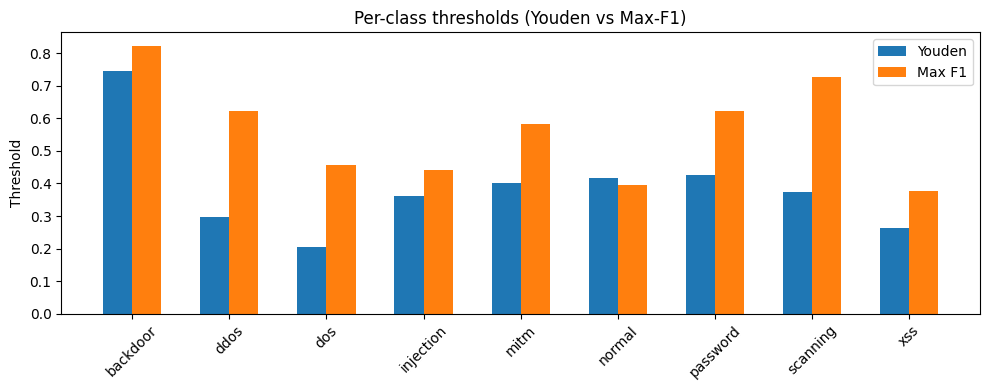

In [11]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, f1_score,
    classification_report, confusion_matrix
)
import numpy as np
import pandas as pd

# ---------- Choose which dataset to tune thresholds on ----------
# Use validation set if available. If not, you can use test (less recommended).
# Replace y_val_seq / X_val_seq with your validation arrays if you have them.
y_tune = y_val_seq if 'y_val_seq' in globals() else y_test_seq

y_pred_probs = model.predict(X_test_seq)

n_classes = y_tune.shape[1]

# ---------- Find thresholds per class ----------
youden_thresholds = np.zeros(n_classes)
f1_thresholds = np.zeros(n_classes)
roc_aucs = np.zeros(n_classes)
pr_aucs = np.zeros(n_classes)

for i in range(n_classes):
    y_true_i = y_tune[:, i]
    y_prob_i = probs_tune[:, i]

    # ROC / Youden's J (maximize TPR - FPR)
    fpr_i, tpr_i, thr_roc = roc_curve(y_true_i, y_prob_i)
    j_scores = tpr_i - fpr_i
    best_idx = np.nanargmax(j_scores)
    youden_thresholds[i] = thr_roc[best_idx]
    roc_aucs[i] = roc_auc_score(y_true_i, y_prob_i)

    # Precision-Recall -> maximize F1 (computed from precision/recall curve)
    precision_i, recall_i, thr_pr = precision_recall_curve(y_true_i, y_prob_i)
    # compute f1 for each precision/recall pair (note thr_pr has len = len(precision)-1)
    # avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * (precision_i * recall_i) / (precision_i + recall_i + 1e-12)
    # precision_recall_curve returns precision/recall points where thresholds correspond to all but last
    # pick the threshold that gives the maximum F1 (ignore last element that has no threshold)
    best_f1_idx = np.nanargmax(f1_scores[:-1])
    # thr_pr aligns with f1_scores[:-1]
    f1_thresholds[i] = thr_pr[best_f1_idx] if len(thr_pr) > 0 else 0.5
    # PR AUC (area under PR curve) can be approximated via sklearn's auc on recall/precision (optional)
    pr_aucs[i] = np.trapz(precision_i, recall_i)  # PR AUC approx

# show thresholds
thresholds_df = pd.DataFrame({
    "Class": type_encoder.classes_,
    "Youden_threshold": youden_thresholds,
    "F1_threshold": f1_thresholds,
    "ROC_AUC": roc_aucs,
    "PR_AUC": pr_aucs
})
print(thresholds_df.to_string(index=False))

# ---------- Select the method you want ----------
best_by = 'f1'   # options: 'youden' or 'f1'
thresholds = f1_thresholds if best_by == 'f1' else youden_thresholds
print(f"\nUsing thresholds selected by: {best_by}")

# ---------- Apply thresholds to predicted probabilities ----------
# Strategy: zero-out any class probability below its class-specific threshold,
# then take argmax over the adjusted probabilities. Fallback: if all zeros, use original argmax.
probs_adj = y_pred_probs.copy()

for i in range(n_classes):
    mask = probs_adj[:, i] < thresholds[i]
    probs_adj[mask, i] = 0.0

# If any sample has all zeros after thresholding, fallback to original probs for that sample
all_zero_mask = (probs_adj.sum(axis=1) == 0)
if all_zero_mask.any():
    probs_adj[all_zero_mask] = y_pred_probs[all_zero_mask]

y_pred_adj = probs_adj.argmax(axis=1)
y_true = y_test_seq.argmax(axis=1)

# ---------- Metrics after thresholding ----------
print("Classification report (after thresholding):\n")
print(classification_report(y_true, y_pred_adj, target_names=type_encoder.classes_))

cm_adj = confusion_matrix(y_true, y_pred_adj)
print("Confusion matrix (after thresholding):")
print(cm_adj)

# ---------- Compute per-class FNR/FPR again (optional) ----------
fnr = []
fpr = []
for i in range(cm_adj.shape[0]):
    fn = cm_adj[i, :].sum() - cm_adj[i, i]
    tp = cm_adj[i, i]
    fp = cm_adj[:, i].sum() - cm_adj[i, i]
    tn = cm_adj.sum() - (tp + fn + fp)
    fnr.append(fn / (fn + tp) if (fn + tp) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

results_df = pd.DataFrame({
    "Class": type_encoder.classes_,
    "FNR_after_threshold": fnr,
    "FPR_after_threshold": fpr
})
print(results_df.to_string(index=False))

# ---------- Optional: Plot decision thresholds per class (visual) ----------
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
x = np.arange(len(type_encoder.classes_))
plt.bar(x - 0.15, youden_thresholds, width=0.3, label='Youden')
plt.bar(x + 0.15, f1_thresholds, width=0.3, label='Max F1')
plt.xticks(x, type_encoder.classes_, rotation=45)
plt.ylabel('Threshold')
plt.title('Per-class thresholds (Youden vs Max-F1)')
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Note about where to choose thresholds ----------
# IMPORTANT: compute thresholds on your validation dataset (X_val_seq / y_val_seq).
# Do NOT use test set for threshold selection if you want an unbiased test evaluation.


['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password' 'scanning'
 'xss']
Encoded class 0 -> backdoor
Encoded class 1 -> ddos
Encoded class 2 -> dos
Encoded class 3 -> injection
Encoded class 4 -> mitm
Encoded class 5 -> normal
Encoded class 6 -> password
Encoded class 7 -> scanning
Encoded class 8 -> xss
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3999
           1       0.93      0.98      0.95      3999
           2       0.95      0.97      0.96      4000
           3       0.96      0.98      0.97      3999
           4       0.35      0.94      0.51       209
           5       1.00      0.98      0.99     59995
           6       0.93      1.00      0.96      3999
           7       0.97      0.99      0.98      4000
           8       0.99      0.95      0.97      4000

    accuracy                           0.98     88200
   macro avg       0.90      0.98      0.92 

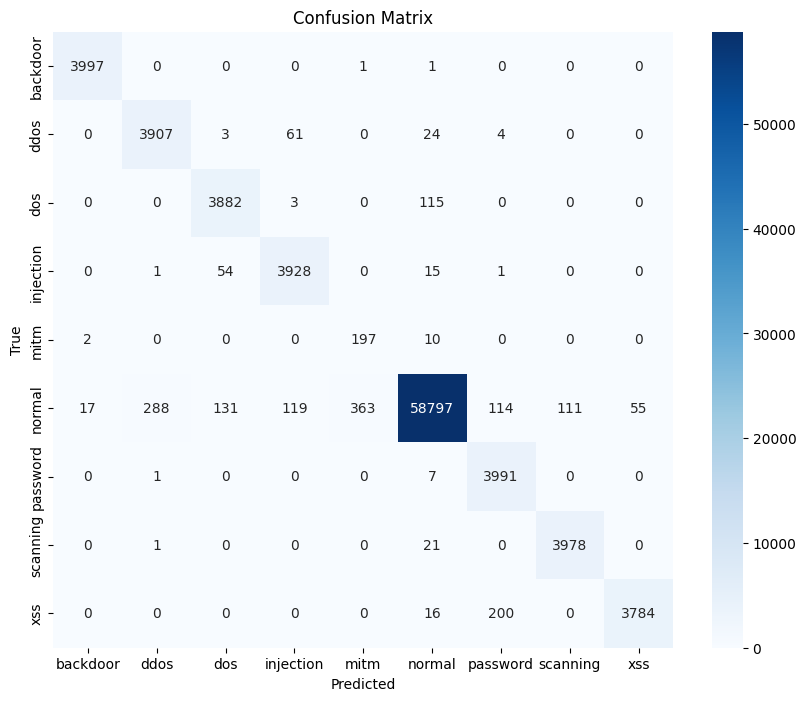

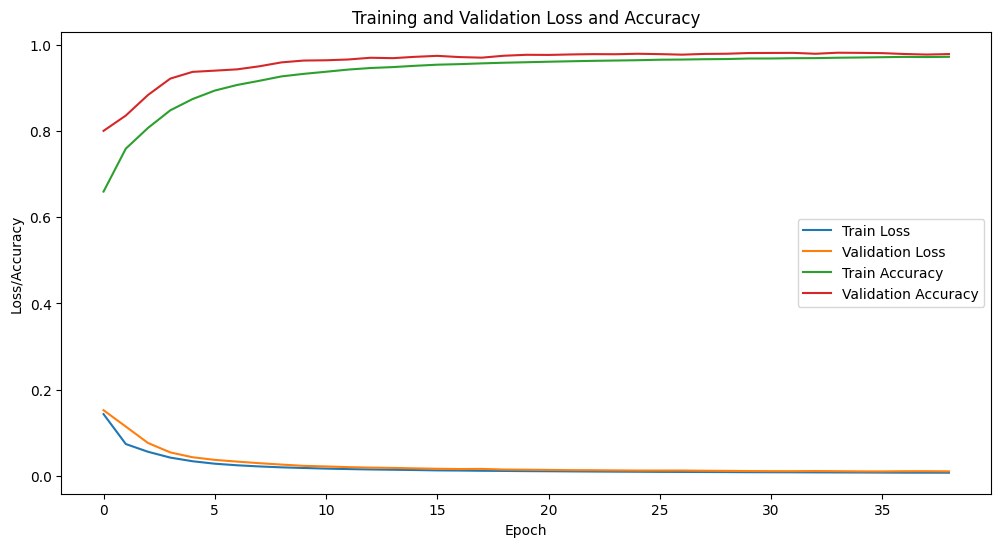

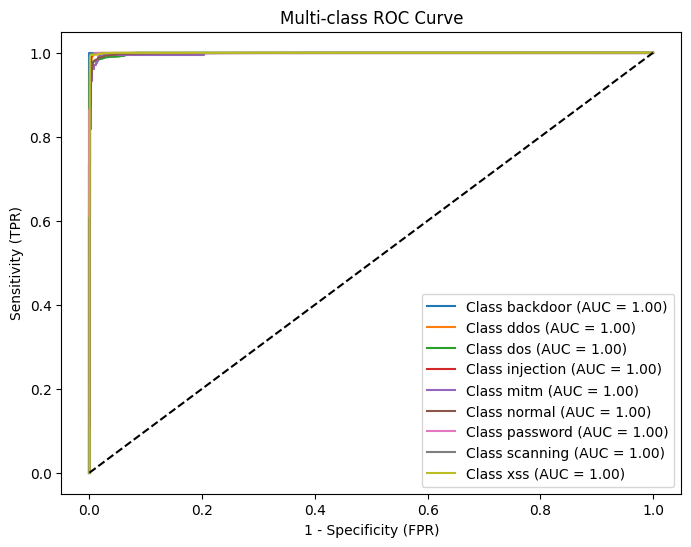

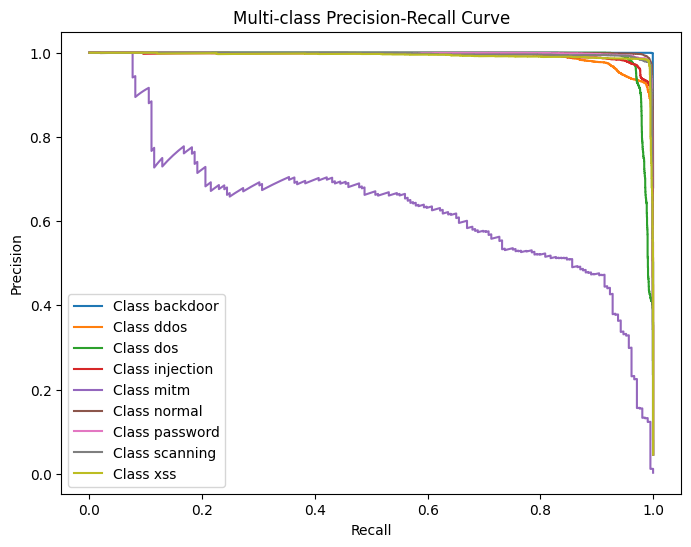

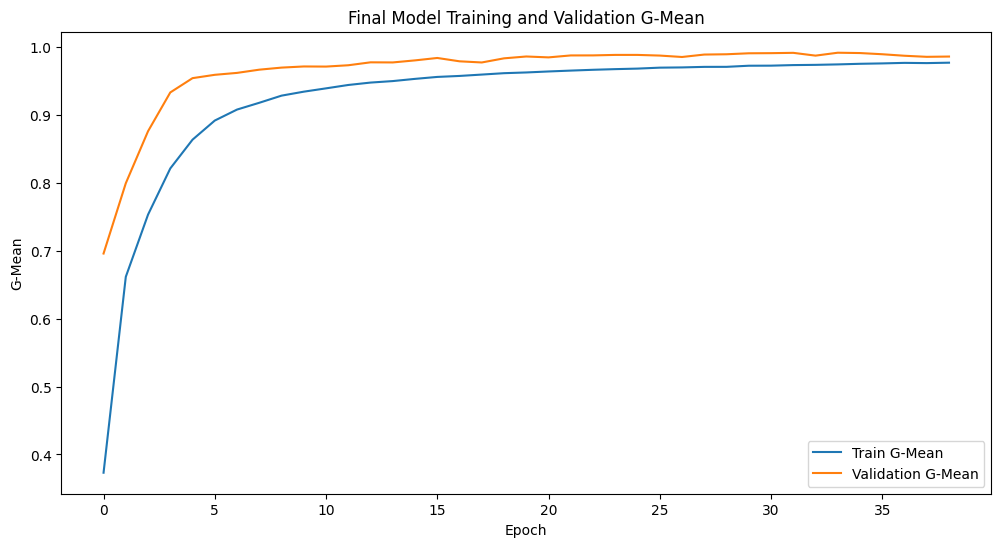

In [ ]:
import seaborn as sns

# original class labels (what was in df[TARGET_TYPE])
print(type_encoder.classes_)

# numeric codes assigned
for i, cls in enumerate(type_encoder.classes_):
    print(f"Encoded class {i} -> {cls}")


# Print classification report
y_pred_probs = model.predict(X_test_seq)
y_pred_classes = y_pred_probs.argmax(axis=1)
y_true_classes = y_test_seq.argmax(axis=1)
print(classification_report(y_true_classes, y_pred_classes))

#confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# For multi-class, FNR and FPR are not simply tn, fp, fn, tp.
# If you want per-class FNR/FPR:
fnr = []
fpr = []
for i in range(cm.shape[0]):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - (tp + fn + fp)
    fnr.append(fn / (fn + tp) if (fn + tp) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

results_df = pd.DataFrame({
    "Class": type_encoder.classes_,
    "FNR": fnr,
    "FPR": fpr
})
print(results_df.to_string(index=False))


# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=type_encoder.classes_,
            yticklabels=type_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# plot validation loss and accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()

# sensitivity vs 1-specificity plot for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    fpr_i, tpr_i, _ = roc_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(fpr_i, tpr_i, label=f'Class {type_encoder.classes_[i]} (AUC = {roc_auc_score(y_test_seq[:, i], y_pred_probs[:, i]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('Multi-class ROC Curve')
plt.xlabel('1 - Specificity (FPR)')
plt.ylabel('Sensitivity (TPR)')
plt.legend()
plt.show()  

# precision-recall curve for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    precision_i, recall_i, _ = precision_recall_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(recall_i, precision_i, label=f'Class {type_encoder.classes_[i]}')
plt.title('Multi-class Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision') 
plt.legend()
plt.show()

# gmean history
plt.figure(figsize=(12, 6))
plt.plot(history.history['multi_class_gmean'], label='Train G-Mean')
plt.plot(history.history['val_multi_class_gmean'], label='Validation G-Mean')
plt.title('Final Model Training and Validation G-Mean')
plt.xlabel('Epoch')
plt.ylabel('G-Mean')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.metrics import Precision
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, AUC
from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, matthews_corrcoef, roc_auc_score, classification_report, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts


# Model definition
model = Sequential([
    Bidirectional(LSTM(
        448,                       
        return_sequences=True,
        recurrent_dropout=0.1,
        recurrent_activation='sigmoid',
        activation='tanh',
        kernel_regularizer=l2(1e-5)
    ), input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LayerNormalization(),
    Dropout(0.1),

    Bidirectional(LSTM(
        192,
        recurrent_dropout=0.3,
        recurrent_activation='sigmoid', 
        activation='tanh',
        kernel_regularizer=l2(1e-5)
    )),
    LayerNormalization(),
    Dropout(0.3),

    Dense(56, activation='relu', kernel_regularizer=l2(1e-5)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(9, activation='softmax')
])

model.summary()

lr_schedule = CosineDecayRestarts(initial_learning_rate=0.00103, first_decay_steps=5)
optimizer = Adam(learning_rate=lr_schedule, clipnorm=1.0)

optimizer = Adam(
    learning_rate=0.0001,  # Very low initial LR 0.0002 <> 0.0001
    clipnorm=1.0,  # Gradient clipping to prevent exploding gradients
)

model.compile(
    optimizer=optimizer,
    loss=focal_loss(gamma=1.0, alpha=0.2),
    metrics=[
        'accuracy', 
        AUC(name='auc'), 
        Recall(), 
        Precision(), 
        MultiClassGMeanMetric(num_classes=y_train_seq_final.shape[1])
    ])

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

frequencies = np.sum(y_train_seq_final, axis=0)
median_freq = np.median(frequencies)
class_weights = {cls: median_freq / count for cls, count in enumerate(frequencies)}

# Train
bhistory = model.fit(
    X_train_seq_final, y_train_seq_final,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=128,
    shuffle=False,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1
)

results = model.evaluate(X_test_seq, y_test_seq, verbose=2)

print("Test Loss: {}".format(results[0]))
print("Test Accuracy: {}".format(results[1]))


/home/jinesh-subedi/htdocs/thesis/thesisStudy/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 10, 896)        │     1,766,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 10, 896)        │         1,792 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 896)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 384)            │     1,672,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 384)            │           768 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 56)             │        21,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,465,857 (13.22 MB)

 Trainable params: 3,465,857 (13.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 178s 74ms/step - accuracy: 0.7129 - auc: 0.9519 - loss: 0.0690 - multi_class_gmean: 0.5531 - precision_1: 0.8777 - recall_1: 0.5810 - val_accuracy: 0.8473 - val_auc: 0.9893 - val_loss: 0.0701 - val_multi_class_gmean: 0.8031 - val_precision_1: 0.9346 - val_recall_1: 0.7541
Epoch 2/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 169s 74ms/step - accuracy: 0.8455 - auc: 0.9873 - loss: 0.0347 - multi_class_gmean: 0.8160 - precision_1: 0.9155 - recall_1: 0.7751 - val_accuracy: 0.9323 - val_auc: 0.9966 - val_loss: 0.0364 - val_multi_class_gmean: 0.9359 - val_precision_1: 0.9544 - val_recall_1: 0.9106
Epoch 3/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 170s 74ms/step - accuracy: 0.8975 - auc: 0.9936 - loss: 0.0228 - multi_class_gmean: 0.8842 - precision_1: 0.9346 - recall_1: 0.8545 - val_accuracy: 0.9570 - val_auc: 0.9979 - val_loss: 0.0261 - val_multi_class_gmean: 0.9629 - val_precision_1: 0.9700 - val_recall_1: 0.9382
Epoch 4/50
2299/2299 ━━━━━━━━━━━━━━━━━━━━ 170s 74ms/ste

In [ ]:
#threshold optimization for ech class


['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password' 'scanning'
 'xss']
Encoded class 0 -> backdoor
Encoded class 1 -> ddos
Encoded class 2 -> dos
Encoded class 3 -> injection
Encoded class 4 -> mitm
Encoded class 5 -> normal
Encoded class 6 -> password
Encoded class 7 -> scanning
Encoded class 8 -> xss
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3999
           1       0.98      0.99      0.98      3999
           2       0.98      0.96      0.97      4000
           3       0.97      0.99      0.98      3999
           4       0.41      0.96      0.57       209
           5       1.00      0.99      0.99     59995
           6       0.95      1.00      0.97      3999
           7       0.98      0.99      0.99      4000
           8       0.99      0.96      0.97      4000

    accuracy                           0.99     88200
   macro avg       0.92      0.98      0.94

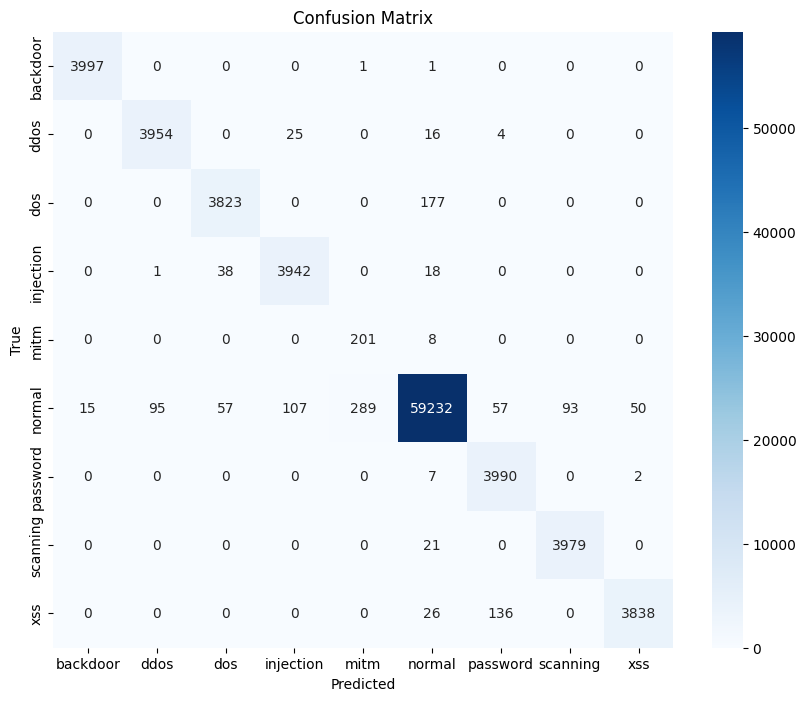

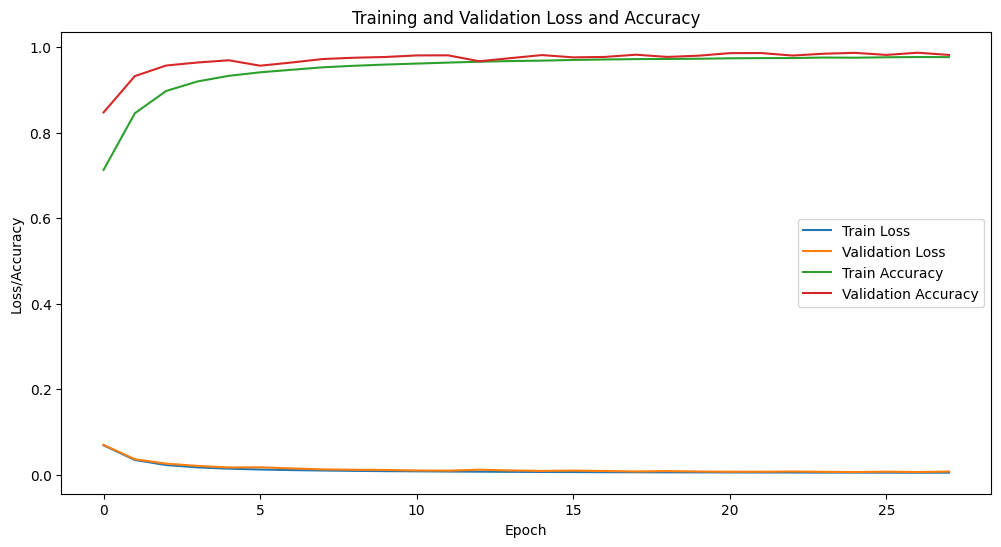

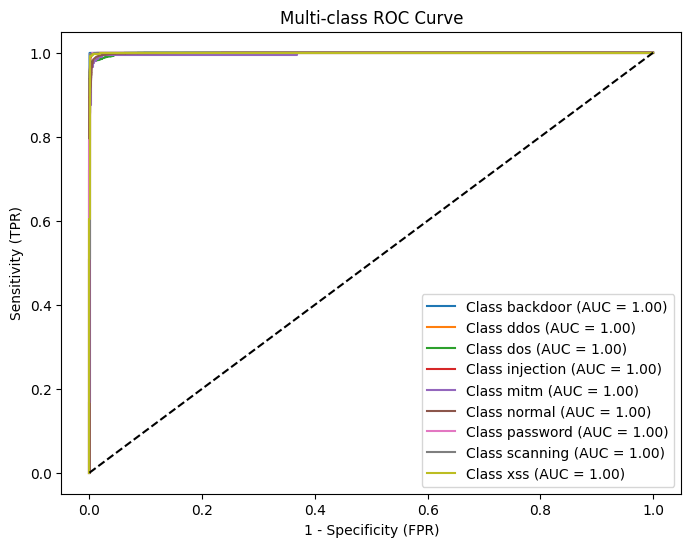

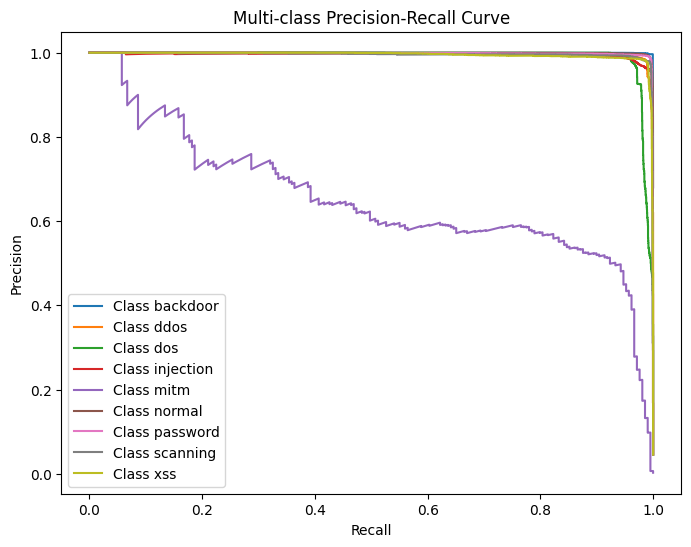

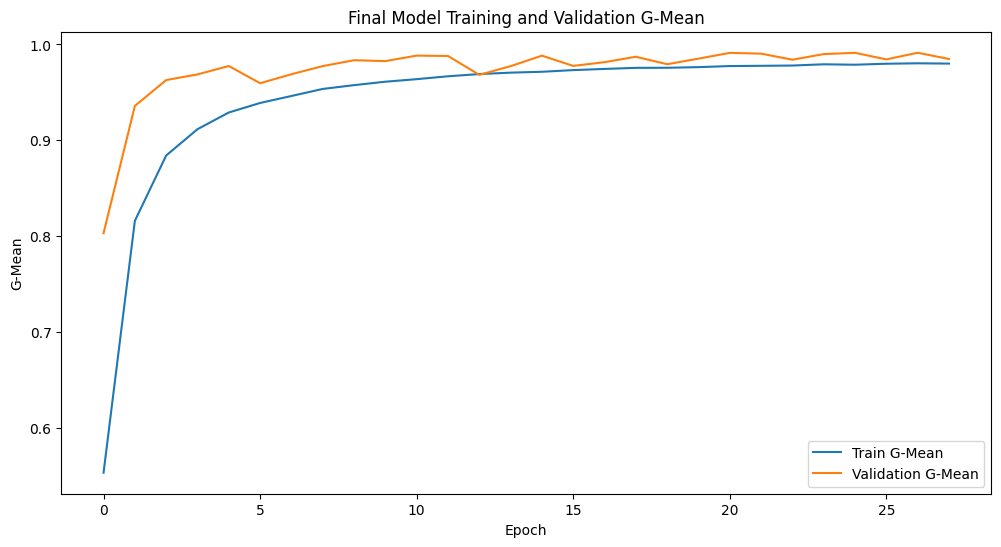

In [ ]:
import seaborn as sns

# original class labels (what was in df[TARGET_TYPE])
print(type_encoder.classes_)

# numeric codes assigned
for i, cls in enumerate(type_encoder.classes_):
    print(f"Encoded class {i} -> {cls}")


# Print classification report
y_pred_probs = model.predict(X_test_seq)
y_pred_classes = y_pred_probs.argmax(axis=1)
y_true_classes = y_test_seq.argmax(axis=1)
print(classification_report(y_true_classes, y_pred_classes))

#confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# For multi-class, FNR and FPR are not simply tn, fp, fn, tp.
# If you want per-class FNR/FPR:
fnr = []
fpr = []
for i in range(cm.shape[0]):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - (tp + fn + fp)
    fnr.append(fn / (fn + tp) if (fn + tp) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

results_df = pd.DataFrame({
    "Class": type_encoder.classes_,
    "FNR": fnr,
    "FPR": fpr
})
print(results_df.to_string(index=False))


# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=type_encoder.classes_,
            yticklabels=type_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# plot validation loss and accuracy
plt.figure(figsize=(12, 6))
plt.plot(bhistory.history['loss'], label='Train Loss')
plt.plot(bhistory.history['val_loss'], label='Validation Loss')
plt.plot(bhistory.history['accuracy'], label='Train Accuracy')
plt.plot(bhistory.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()

# sensitivity vs 1-specificity plot for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    fpr_i, tpr_i, _ = roc_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(fpr_i, tpr_i, label=f'Class {type_encoder.classes_[i]} (AUC = {roc_auc_score(y_test_seq[:, i], y_pred_probs[:, i]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title('Multi-class ROC Curve')
plt.xlabel('1 - Specificity (FPR)')
plt.ylabel('Sensitivity (TPR)')
plt.legend()
plt.show()  

# precision-recall curve for multi-class
plt.figure(figsize=(8, 6))
for i in range(len(type_encoder.classes_)):
    precision_i, recall_i, _ = precision_recall_curve(y_test_seq[:, i], y_pred_probs[:, i])
    plt.plot(recall_i, precision_i, label=f'Class {type_encoder.classes_[i]}')
plt.title('Multi-class Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision') 
plt.legend()
plt.show()

# gmean history
plt.figure(figsize=(12, 6))
plt.plot(bhistory.history['multi_class_gmean'], label='Train G-Mean')
plt.plot(bhistory.history['val_multi_class_gmean'], label='Validation G-Mean')
plt.title('Final Model Training and Validation G-Mean')
plt.xlabel('Epoch')
plt.ylabel('G-Mean')
plt.legend()
plt.show()
